In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [8]:
df = pd.read_csv('./src/placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,3.25,41.97,0
1,2.93,27.00,1
2,3.32,23.88,1
3,3.76,24.25,0
4,2.88,8.91,0


C:\Users\MuhammadAbdullah\AppData\Local\Temp\ipykernel_2456\3582099395.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\MuhammadAbdullah\AppData\Local\Temp\ipykernel_2456\3582099395.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


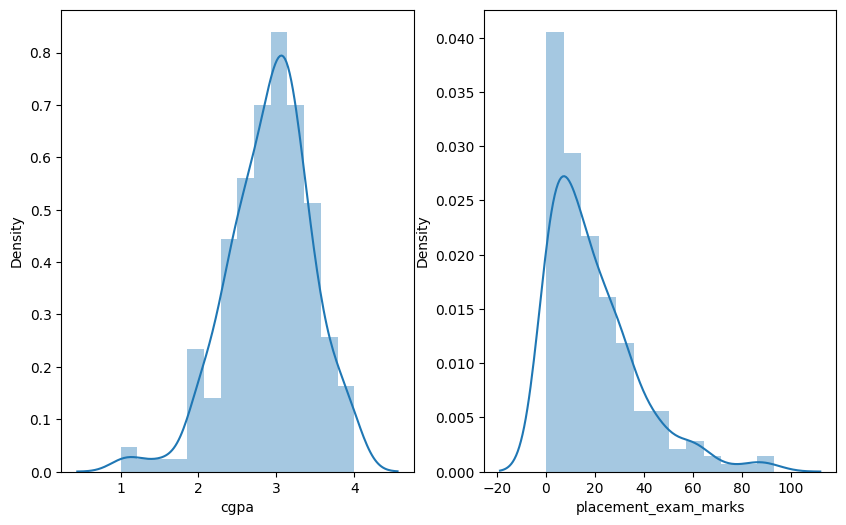

In [9]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])
plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])
plt.show()

In [10]:
df.describe()

,cgpa,placement_exam_marks,placed
count,200.000000,200.000000,200.000000
mean,2.914650,19.334400,0.515000
std,0.534712,18.108324,0.501029
min,1.000000,0.220000,0.000000
25%,2.587500,5.742500,0.000000
50%,2.970000,14.425000,1.000000
75%,3.240000,27.940000,1.000000
max,4.000000,93.140000,1.000000


In [11]:
print("Highest Allowed CGPA:", df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest Allowed CGPA:", df['cgpa'].mean() - 3*df['cgpa'].std())

Highest Allowed CGPA: 4.518784700762675
Lowest Allowed CGPA: 1.310515299237326


In [12]:
df[(df['cgpa'] > 4.51)|(df['cgpa'] < 1.31)]

,cgpa,placement_exam_marks,placed
7,1.28,33.23,0
8,1.09,40.36,1
9,1.00,48.89,0


### Trimming

In [ ]:
# Approach 1
new_df = df[(df['cgpa'] <= 4.51) & (df['cgpa'] >= 1.31)]
new_df

,cgpa,placement_exam_marks,placed
0,3.25,41.97,0
1,2.93,27.00,1
2,3.32,23.88,1
3,3.76,24.25,0
4,2.88,8.91,0
...,...,...,...
195,3.19,2.53,1
196,2.56,2.50,0
197,3.08,20.95,0
198,3.03,27.41,0


In [16]:
# Approach 2
df['cgpa_z_score'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()
df[['cgpa_z_score']]

,cgpa_z_score
0,0.627161
1,0.028707
2,0.758072
3,1.580946
4,-0.064801
...,...
195,0.514951
196,-0.663255
197,0.309232
198,0.215724


In [17]:
df[(df['cgpa_z_score'] > 3)|(df['cgpa_z_score'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_z_score
7,1.28,33.23,0,-3.057069
8,1.09,40.36,1,-3.412400
9,1.00,48.89,0,-3.580716


In [19]:
new2_df = df[(df['cgpa_z_score'] <= 3) & (df['cgpa_z_score'] >= -3)]
new2_df

,cgpa,placement_exam_marks,placed,cgpa_z_score
0,3.25,41.97,0,0.627161
1,2.93,27.00,1,0.028707
2,3.32,23.88,1,0.758072
3,3.76,24.25,0,1.580946
4,2.88,8.91,0,-0.064801
...,...,...,...,...
195,3.19,2.53,1,0.514951
196,2.56,2.50,0,-0.663255
197,3.08,20.95,0,0.309232
198,3.03,27.41,0,0.215724


### Capping

In [20]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [21]:
upper_limit, lower_limit

(np.float64(4.518784700762675), np.float64(1.310515299237326))

In [22]:
df.describe()

,cgpa,placement_exam_marks,placed,cgpa_z_score
count,200.000000,200.000000,200.000000,2.000000e+02
mean,2.914650,19.334400,0.515000,-7.460699e-16
std,0.534712,18.108324,0.501029,1.000000e+00
min,1.000000,0.220000,0.000000,-3.580716e+00
25%,2.587500,5.742500,0.000000,-6.118252e-01
50%,2.970000,14.425000,1.000000,1.035138e-01
75%,3.240000,27.940000,1.000000,6.084589e-01
max,4.000000,93.140000,1.000000,2.029786e+00


In [23]:
df['cgpa'] = np.where(df['cgpa'] > upper_limit, upper_limit, np.where(df['cgpa'] < lower_limit, lower_limit, df['cgpa']))

In [24]:
df.describe()

,cgpa,placement_exam_marks,placed,cgpa_z_score
count,200.000000,200.000000,200.000000,2.000000e+02
mean,2.917458,19.334400,0.515000,-7.460699e-16
std,0.525473,18.108324,0.501029,1.000000e+00
min,1.310515,0.220000,0.000000,-3.580716e+00
25%,2.587500,5.742500,0.000000,-6.118252e-01
50%,2.970000,14.425000,1.000000,1.035138e-01
75%,3.240000,27.940000,1.000000,6.084589e-01
max,4.000000,93.140000,1.000000,2.029786e+00


In [26]:
df.shape

(200, 4)